# Mapas temáticos de las Slope Units

Cuatro mapas categóricos del Valle de Aburrá sobre el conjunto final de slope units (SU):

1. **Tipos de suelo** (`suelos`)
2. **Cobertura del suelo** (`cobertura`, recodificada)
3. **Zonas de lluvia** (`zona_lluvia`)
4. **Tipo de slope unit** (`su_type`)

Las decisiones de paleta están razonadas en cada celda; los `NaN` se preservan en el mapa como categoría "Sin dato" para no introducir huecos espaciales engañosos.

## 1. Imports y carga

In [1]:
from pathlib import Path
from typing import Optional

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D

# Si ya generaste el GPKG recodificado en el paso previo, úsalo:
INPUT_PATH  = Path('slope_units_cobertura_recodificada.gpkg')
INPUT_LAYER = 'slope_units_final'

# Si todavía no, descomenta esto para leer el original:
# INPUT_PATH  = Path('/mnt/user-data/uploads/slope_units_final.gpkg')
# INPUT_LAYER = 'slope_units_final'

gdf = gpd.read_file(INPUT_PATH, layer=INPUT_LAYER)
print(f'CRS   : {gdf.crs}')
print(f'SU    : {len(gdf):,}')

CRS   : EPSG:3116
SU    : 61,242


## 2. Función helper para mapas categóricos

Centralizamos el estilo: extensión, escala, leyenda externa, manejo de NaN, sin ejes ruidosos. Así los cuatro mapas son visualmente comparables (lo cual importa si vas a ponerlos juntos en la tesis).

In [2]:
def mapa_categorico(
    gdf: gpd.GeoDataFrame,
    columna: str,
    titulo: str,
    color_dict: dict,
    orden: Optional[list] = None,
    color_nan: str = '#d9d9d9',
    figsize: tuple = (8, 10),
    edgecolor: Optional[str] = None,
    linewidth: float = 0.0,
    titulo_leyenda: Optional[str] = None,
) -> plt.Figure:
    """Dibuja un mapa categórico con leyenda controlada manualmente.

    Parameters
    ----------
    gdf : GeoDataFrame proyectado.
    columna : columna a clasificar.
    titulo : título del mapa.
    color_dict : dict {valor_categoria: color_hex}. Define qué clases pinta y con
        qué color. Cualquier valor fuera del dict se considera NaN.
    orden : opcional, orden de las clases en la leyenda. Si es None,
        se usa el orden de inserción de `color_dict`.
    color_nan : color para registros sin clase asignada (NaN o no listada).
    figsize : tamaño de la figura (in).
    edgecolor, linewidth : borde de los polígonos.
    titulo_leyenda : título sobre la leyenda; por defecto, igual a `columna`.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if titulo_leyenda is None:
        titulo_leyenda = columna

    # Asignar color por fila. Lo que no esté en color_dict (incluye NaN) -> color_nan
    colores = gdf[columna].map(color_dict).fillna(color_nan)

    fig, ax = plt.subplots(figsize=figsize)
    gdf.plot(
        ax=ax,
        color=colores,
        edgecolor=edgecolor if edgecolor else 'none',
        linewidth=linewidth,
    )
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_title(titulo, fontsize=13, weight='bold', pad=10)

    # Leyenda manual (controlamos orden y mostramos categoría 'Sin dato' solo si aplica)
    clases = orden if orden is not None else list(color_dict.keys())
    handles = [
        mpatches.Patch(facecolor=color_dict[c], edgecolor='black', linewidth=0.3, label=str(c))
        for c in clases
    ]
    if gdf[columna].isna().any() or (~gdf[columna].isin(color_dict)).any():
        handles.append(
            mpatches.Patch(facecolor=color_nan, edgecolor='black', linewidth=0.3, label='Sin dato')
        )

    ax.legend(
        handles=handles,
        title=titulo_leyenda,
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
        fontsize=10,
        title_fontsize=11,
    )

    # Escala simple (km), abajo a la izquierda. Asume CRS proyectado en metros.
    _agregar_escala(ax, gdf, longitud_km=5)

    fig.tight_layout()
    return fig


def _agregar_escala(ax, gdf, longitud_km=5):
    """Dibuja una barra de escala discreta en la esquina inferior izquierda."""
    minx, miny, maxx, maxy = gdf.total_bounds
    span_x = maxx - minx
    span_y = maxy - miny
    # 5 km en unidades del CRS (m). Posición: 5% desde el borde inferior izquierdo.
    x0 = minx + 0.05 * span_x
    y0 = miny + 0.05 * span_y
    ax.plot([x0, x0 + longitud_km * 1000], [y0, y0], color='black', linewidth=2.5,
            solid_capstyle='butt')
    ax.text(x0 + longitud_km * 500, y0 + 0.012 * span_y, f'{longitud_km} km',
            ha='center', va='bottom', fontsize=9)
    # Norte
    xn = maxx - 0.05 * span_x
    yn = miny + 0.07 * span_y
    ax.annotate('N', xy=(xn, yn + 0.04 * span_y), xytext=(xn, yn),
                ha='center', fontsize=11, weight='bold',
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.3))

## 3. Mapa de tipos de suelo

Paleta cualitativa Set2: bajo contraste cromático y legible en B/N (criterio de figura publicable).

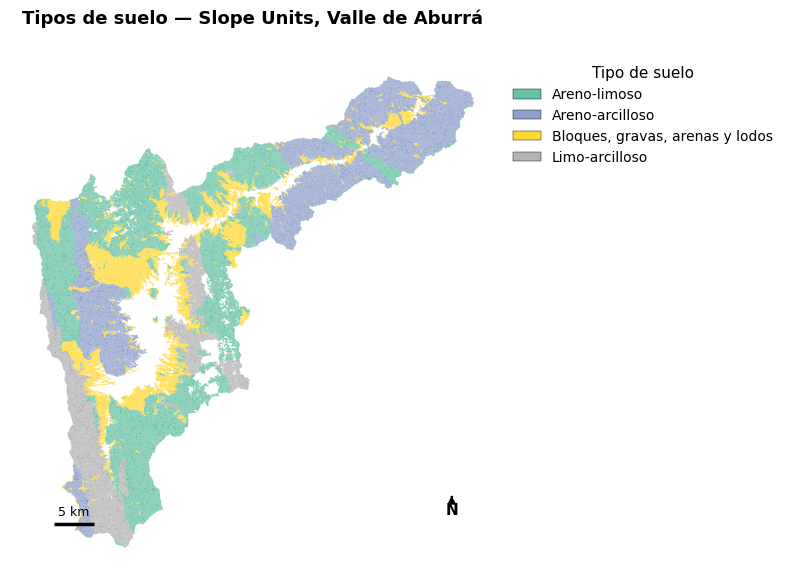

In [3]:
categorias_suelo = (
    gdf['suelos']
    .value_counts()
    .index
    .tolist()
)

cmap_set2 = plt.get_cmap('Set2', len(categorias_suelo))
color_suelos = {cat: to_hex(cmap_set2(i)) for i, cat in enumerate(categorias_suelo)}

fig = mapa_categorico(
    gdf,
    columna='suelos',
    titulo='Tipos de suelo — Slope Units, Valle de Aburrá',
    color_dict=color_suelos,
    titulo_leyenda='Tipo de suelo',
)
plt.show()

## 4. Mapa de cobertura

Paleta **semántica manual**: el lector reconoce la clase por el color sin necesidad de la leyenda — gris para urbano consolidado, naranja para urbano disperso, amarillo agrícola, verde bosque, marrón para superficies degradadas.

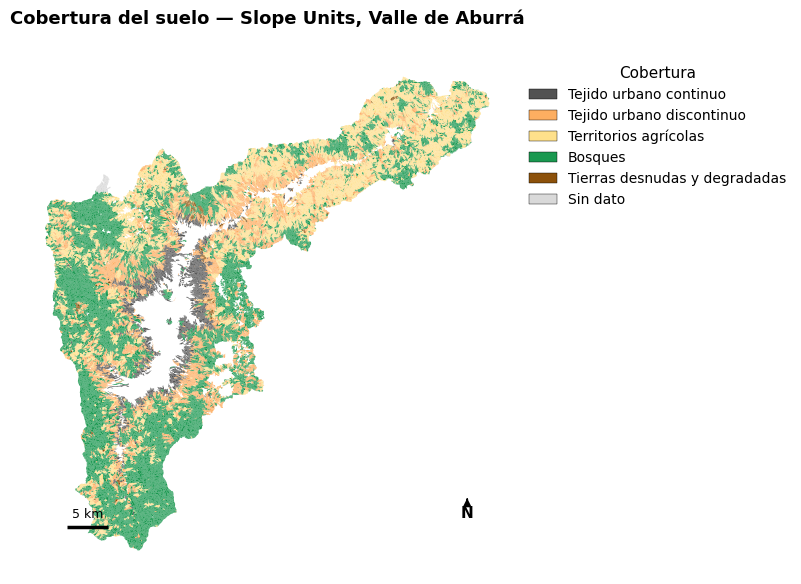

In [4]:
color_cobertura = {
    'Tejido urbano continuo':        '#525252',  # gris oscuro
    'Tejido urbano discontinuo':     '#fdae61',  # naranja claro
    'Territorios agrícolas':         '#fee08b',  # amarillo
    'Bosques':                       '#1a9850',  # verde oscuro
    'Tierras desnudas y degradadas': '#8c510a',  # marrón
}

orden_cobertura = [
    'Tejido urbano continuo',
    'Tejido urbano discontinuo',
    'Territorios agrícolas',
    'Bosques',
    'Tierras desnudas y degradadas',
]

fig = mapa_categorico(
    gdf,
    columna='cobertura',
    titulo='Cobertura del suelo — Slope Units, Valle de Aburrá',
    color_dict=color_cobertura,
    orden=orden_cobertura,
    titulo_leyenda='Cobertura',
)
plt.show()

## 5. Mapa de zonas de lluvia

Paleta **viridis** (secuencial, perceptualmente uniforme). Asumo que las zonas 1→5 reflejan un gradiente físico (p. ej. acumulado o intensidad). Si en tu zonificación las clases son nominales (regiones sin orden interno), cambia el cmap a `'tab10'` o `'Set1'`.

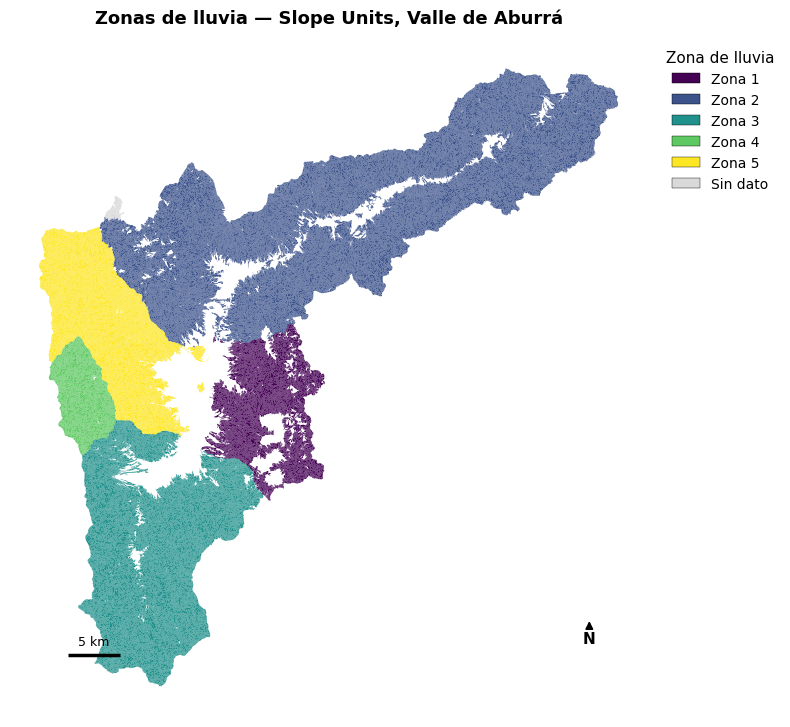

In [5]:
# La columna es float64 por culpa de los NaN; aquí queremos enteros para la leyenda.
zonas = sorted(gdf['zona_lluvia'].dropna().unique())
zonas_int = [int(z) for z in zonas]

cmap_viridis = plt.get_cmap('viridis', len(zonas))
color_zona = {z: to_hex(cmap_viridis(i)) for i, z in enumerate(zonas)}
# Versión con etiquetas legibles (enteros, no '1.0', '2.0')
color_zona_legible = {f'Zona {int(z)}': color_zona[z] for z in zonas}

# Mapeamos el valor numérico a la etiqueta legible solo para graficar/leyenda
gdf_plot = gdf.assign(
    zona_lluvia_lbl=gdf['zona_lluvia'].map(
        lambda v: f'Zona {int(v)}' if not (v is None or np.isnan(v)) else None
    )
)

fig = mapa_categorico(
    gdf_plot,
    columna='zona_lluvia_lbl',
    titulo='Zonas de lluvia — Slope Units, Valle de Aburrá',
    color_dict=color_zona_legible,
    orden=[f'Zona {z}' for z in zonas_int],
    titulo_leyenda='Zona de lluvia',
)
plt.show()

## 6. Mapa de tipo de slope unit (`su_type`)

Paleta cualitativa Set1, contrastada. El `su_type` distingue categorías morfológicas (típicamente laderas vs. cuencas o agregaciones), por eso conviene una paleta que separe bien las clases.

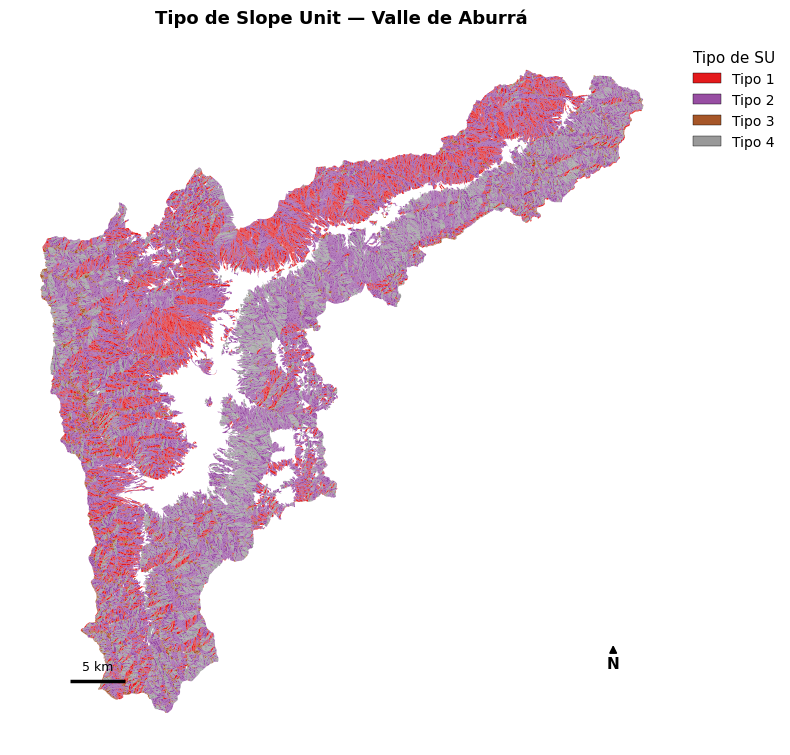

In [6]:
tipos_su = sorted(gdf['su_type'].unique())
cmap_set1 = plt.get_cmap('Set1', len(tipos_su))
color_sutype = {t: to_hex(cmap_set1(i)) for i, t in enumerate(tipos_su)}
color_sutype_legible = {f'Tipo {t}': color_sutype[t] for t in tipos_su}

gdf_plot2 = gdf.assign(
    su_type_lbl=gdf['su_type'].map(lambda t: f'Tipo {int(t)}'),
)

fig = mapa_categorico(
    gdf_plot2,
    columna='su_type_lbl',
    titulo='Tipo de Slope Unit — Valle de Aburrá',
    color_dict=color_sutype_legible,
    orden=[f'Tipo {t}' for t in tipos_su],
    titulo_leyenda='Tipo de SU',
)
plt.show()

## 7. (Opcional) Panel resumen 2×2

Útil si la tesis requiere una figura única que muestre la caracterización global de las SU. Reusa la misma lógica de la función helper, en versión compacta.

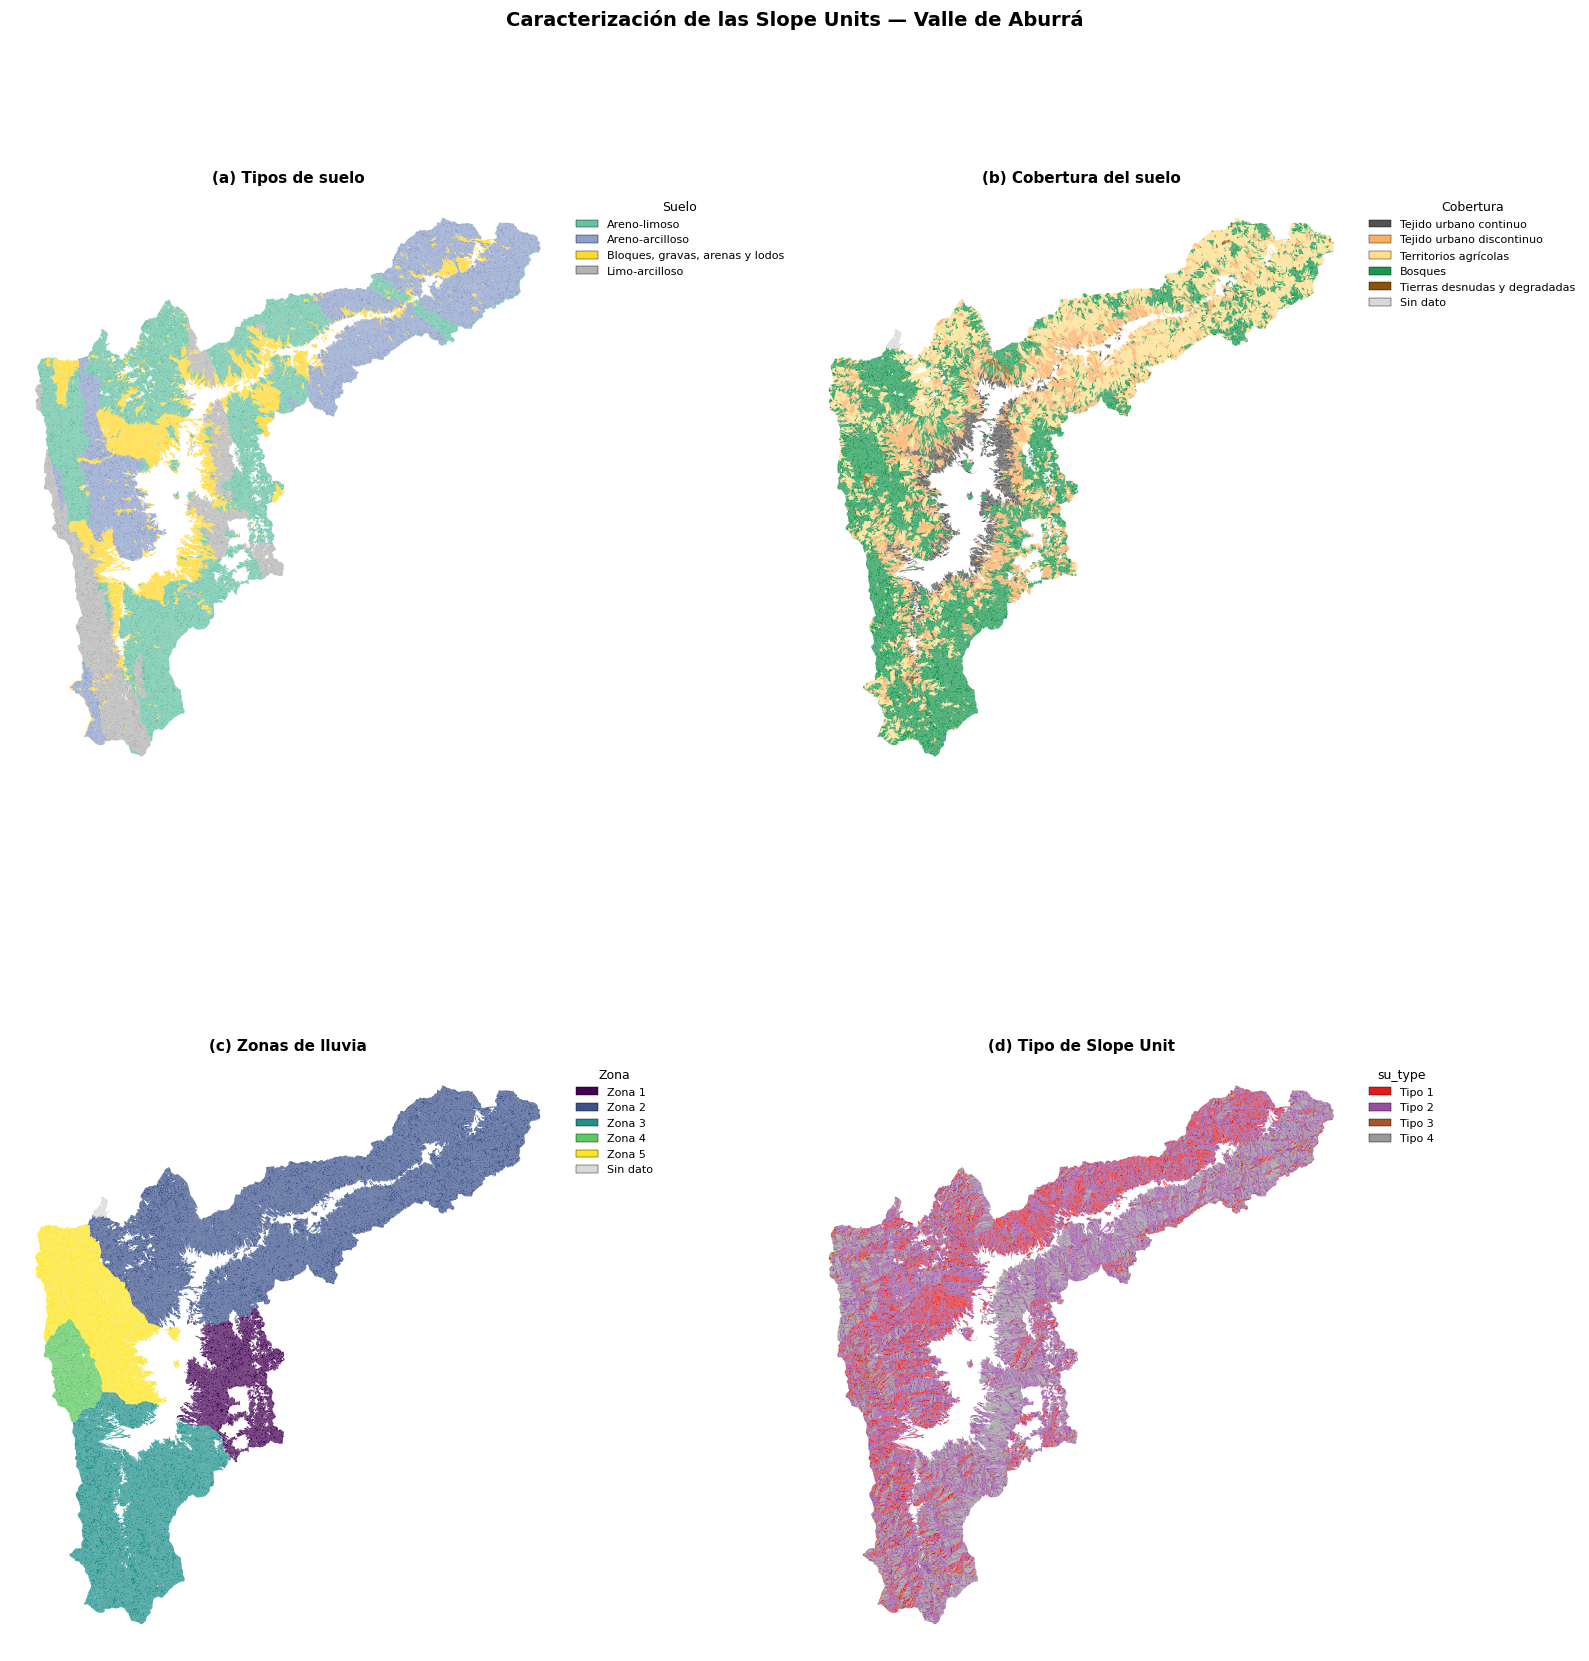

In [7]:
def _plot_en_axis(ax, gdf, columna, color_dict, orden, titulo, titulo_leyenda,
                  color_nan='#d9d9d9'):
    colores = gdf[columna].map(color_dict).fillna(color_nan)
    gdf.plot(ax=ax, color=colores, edgecolor='none', linewidth=0)
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_title(titulo, fontsize=11, weight='bold')
    handles = [mpatches.Patch(facecolor=color_dict[c], edgecolor='black',
                              linewidth=0.3, label=str(c)) for c in orden]
    if gdf[columna].isna().any() or (~gdf[columna].isin(color_dict)).any():
        handles.append(mpatches.Patch(facecolor=color_nan, edgecolor='black',
                                      linewidth=0.3, label='Sin dato'))
    ax.legend(handles=handles, title=titulo_leyenda, loc='upper left',
              bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8,
              title_fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(16, 18))

_plot_en_axis(axes[0, 0], gdf, 'suelos',
              color_suelos, categorias_suelo,
              '(a) Tipos de suelo', 'Suelo')
_plot_en_axis(axes[0, 1], gdf, 'cobertura',
              color_cobertura, orden_cobertura,
              '(b) Cobertura del suelo', 'Cobertura')
_plot_en_axis(axes[1, 0], gdf_plot, 'zona_lluvia_lbl',
              color_zona_legible, [f'Zona {z}' for z in zonas_int],
              '(c) Zonas de lluvia', 'Zona')
_plot_en_axis(axes[1, 1], gdf_plot2, 'su_type_lbl',
              color_sutype_legible, [f'Tipo {t}' for t in tipos_su],
              '(d) Tipo de Slope Unit', 'su_type')

fig.suptitle('Caracterización de las Slope Units — Valle de Aburrá',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
plt.show()

## 8. Inventarios de movimientos en masa: carga y unión espacial

Cargo los dos inventarios disponibles y los uno espacialmente con las SU. Cada MM queda asignado a una única SU (la que lo contiene), heredando así sus atributos categóricos (`suelos`, `cobertura`, `su_type`).

**Inventarios:**

- `INV_CSV` (SIATA / campo): CSV con coordenadas, asume EPSG:4326 si no se indica otro.
- `INV_GEOJSON` (sensores remotos AMVA): GeoJSON, ya geoespacial.

**Validaciones automáticas:**

- Auto-detección de columnas de longitud/latitud en el CSV.
- Reproyección a EPSG:3116 antes del spatial join.
- Reporte de MM que caen fuera del dominio (no se asignan a ninguna SU).


In [10]:
import pandas as pd
# ===== RUTAS A LOS INVENTARIOS =====
# Si tu sistema operativo es distinto, ajusta. Las rutas vienen tal cual las indicaste.
INV_CSV     = Path('/home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv')
INV_GEOJSON = Path('/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/landslides/sensores_remotos_amva.geojson')

# Etiquetas que aparecerán en gráficos y leyendas
LBL_CSV     = 'Inventario histórico'
LBL_GEOJSON = 'Sensores remotos'

# CRS de trabajo: el de las SU (Magna-Sirgas / Origen Bogotá, en metros)
CRS_TRABAJO = 'EPSG:3116'
# CRS asumido para el CSV si no trae uno explícito
CRS_CSV_DEFAULT = 'EPSG:4326'

In [11]:
def cargar_inventario_csv(
    path: Path,
    crs_default: str = 'EPSG:4326',
    crs_destino: str = 'EPSG:3116',
    col_lon: Optional[str] = None,
    col_lat: Optional[str] = None,
) -> gpd.GeoDataFrame:
    """Carga un inventario CSV con coordenadas y lo convierte en GeoDataFrame.

    Si col_lon/col_lat no se pasan, los detecta automáticamente entre nombres
    comunes ('lon'/'lat', 'longitude'/'latitude', 'X'/'Y', etc.).

    Parameters
    ----------
    path : ruta al CSV.
    crs_default : CRS que se asume si el CSV no trae metadatos (típicamente WGS84).
    crs_destino : CRS al que se reproyectará el resultado.
    col_lon, col_lat : nombres explícitos de las columnas de coordenadas. Si son
        None se intenta auto-detección.

    Returns
    -------
    GeoDataFrame en `crs_destino`.
    """
    df = pd.read_csv(path)
    print(f'  CSV leído: {len(df):,} filas, columnas: {df.columns.tolist()}')

    # Auto-detección
    if col_lon is None or col_lat is None:
        cols_lower = {c.lower(): c for c in df.columns}
        candidatos_lon = ['lon', 'long', 'longitude', 'longitud', 'x']
        candidatos_lat = ['lat', 'latitude', 'latitud', 'y']
        for cand in candidatos_lon:
            if cand in cols_lower:
                col_lon = cols_lower[cand]; break
        for cand in candidatos_lat:
            if cand in cols_lower:
                col_lat = cols_lower[cand]; break
        if col_lon is None or col_lat is None:
            raise ValueError(
                f'No pude detectar columnas lon/lat en el CSV. '
                f'Pasa col_lon/col_lat explícitamente. Columnas: {df.columns.tolist()}'
            )
        print(f'  Coordenadas detectadas: lon={col_lon!r}, lat={col_lat!r}')

    # Filtrar filas con coordenadas válidas
    n0 = len(df)
    df = df.dropna(subset=[col_lon, col_lat]).copy()
    n_drop = n0 - len(df)
    if n_drop:
        print(f'  ⚠ {n_drop} filas sin coordenadas, descartadas.')

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[col_lon], df[col_lat]),
        crs=crs_default,
    )
    return gdf.to_crs(crs_destino)


def cargar_inventario_geojson(
    path: Path,
    crs_destino: str = 'EPSG:3116',
) -> gpd.GeoDataFrame:
    """Carga un inventario GeoJSON y lo reproyecta al CRS de trabajo."""
    gdf = gpd.read_file(path)
    print(f'  GeoJSON leído: {len(gdf):,} registros, CRS={gdf.crs}')
    if gdf.crs is None:
        raise ValueError('El GeoJSON no trae CRS. Define uno explícito antes de continuar.')
    return gdf.to_crs(crs_destino)


print('--- Cargando inventarios ---')
inv_csv = cargar_inventario_csv(INV_CSV, crs_default=CRS_CSV_DEFAULT, crs_destino=CRS_TRABAJO)
print()
inv_geo = cargar_inventario_geojson(INV_GEOJSON, crs_destino=CRS_TRABAJO)
print()
print(f'  ✓ {LBL_CSV:<30}: {len(inv_csv):,} MM')
print(f'  ✓ {LBL_GEOJSON:<30}: {len(inv_geo):,} MM')

--- Cargando inventarios ---
  CSV leído: 496 filas, columnas: ['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud', 'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo', 'si_no', '1d', '2d', '3d', '4d', '5d', '6d', '7d', '8d', '9d', '10d', '11d', '12d', '13d', '14d', '15d', '16d', '17d', '18d', '19d', '20d', '21d', '22d', '23d', '24d', '25d', '26d', '27d', '28d', '29d', '30d', '31d', '32d', '33d', '34d', '35d', '36d', '37d', '38d', '39d', '40d', '41d', '42d', '43d', '44d', '45d', '46d', '47d', '48d', '49d', '50d', '51d', '52d', '53d', '54d', '55d', '56d', '57d', '58d', '59d', '60d', '61d', '62d', '63d', '64d', '65d', '66d', '67d', '68d', '69d', '70d', '71d', '72d', '73d', '74d', '75d', '76d', '77d', '78d', '79d', '80d', '81d', '82d', '83d', '84d', '85d', '86d', '87d', '88d', '89d', '90d', '91d', '92d', '93d', '94d', '95d', '96d', '97d']
  Coordenadas detectadas: lon='longitud', lat='latitud'

  GeoJSON leído: 5,759 re

In [12]:
def asignar_su(
    inventario: gpd.GeoDataFrame,
    su: gpd.GeoDataFrame,
    cols_su: list,
) -> gpd.GeoDataFrame:
    """Asigna a cada MM la SU que lo contiene, heredando atributos categóricos.

    Parameters
    ----------
    inventario : puntos de MM (en CRS de trabajo).
    su : polígonos de slope units (en CRS de trabajo).
    cols_su : columnas de `su` que se quieren heredar.

    Returns
    -------
    GeoDataFrame con las columnas heredadas. Los MM fuera del dominio quedan
    con NaN en esas columnas (y se reporta cuántos son).
    """
    if inventario.crs != su.crs:
        raise ValueError(f'CRS distintos: {inventario.crs} vs {su.crs}')

    out = gpd.sjoin(
        inventario[['geometry']].reset_index().rename(columns={'index':'_inv_idx'}),
        su[cols_su + ['geometry']],
        predicate='within',
        how='left',
    ).drop(columns=['index_right'], errors='ignore')

    fuera = out[cols_su[0]].isna().sum()
    print(f'  Total MM: {len(inventario):,} | dentro del dominio: {len(out)-fuera:,} | '
          f'fuera: {fuera:,} ({fuera/len(inventario)*100:.1f}%)')
    return out


COLS_HEREDAR = ['suelos', 'cobertura', 'su_type']

print(f'--- Spatial join: {LBL_CSV} ---')
mm_csv = asignar_su(inv_csv, gdf, COLS_HEREDAR)
print(f'\n--- Spatial join: {LBL_GEOJSON} ---')
mm_geo = asignar_su(inv_geo, gdf, COLS_HEREDAR)

--- Spatial join: Inventario histórico ---
  Total MM: 496 | dentro del dominio: 479 | fuera: 17 (3.4%)

--- Spatial join: Sensores remotos ---
  Total MM: 5,759 | dentro del dominio: 5,719 | fuera: 40 (0.7%)


## 9. Tabla de abundancia (km²) y densidad de MM (eventos/km²)

Para cada variable categórica calculo:

- `area_km2`: suma del área de las SU de esa categoría.
- `n_mm_csv`, `n_mm_geo`: conteo de MM de cada inventario en esa categoría.
- `dens_mm_csv`, `dens_mm_geo`: densidad de MM (eventos/km²) — *la métrica relevante para defender susceptibilidad observada*.


In [13]:
def tabla_abundancia_densidad(
    su: gpd.GeoDataFrame,
    columna: str,
    mm_inventarios: dict,
) -> pd.DataFrame:
    """Tabla de área (km²), conteo y densidad de MM por categoría.

    Parameters
    ----------
    su : GeoDataFrame de SU con columna `area` en m².
    columna : variable categórica de agregación ('suelos', 'cobertura', 'su_type').
    mm_inventarios : dict {etiqueta: GeoDataFrame de MM con la columna heredada}.

    Returns
    -------
    DataFrame ordenado por categoría con columnas:
        area_km2, [n_mm_<inv>, dens_mm_<inv> por cada inventario].
    """
    # Área total por categoría
    # Recalculo el área desde la geometría (en m², por estar en EPSG:3116) -> km².
    # No uso la columna `area` del GPKG porque sus unidades pueden variar entre datasets.
    area_m2 = su.geometry.area
    area_km2 = area_m2.groupby(su[columna].values, dropna=False).sum() / 1e6
    area_km2.index.name = columna

    tabla = pd.DataFrame({'area_km2': area_km2}).round(3)

    for etiq, mm in mm_inventarios.items():
        # Sufijo seguro para nombre de columna
        sfx = ''.join(ch if ch.isalnum() else '_' for ch in etiq.lower())[:20]
        n   = mm.groupby(columna, dropna=False).size().reindex(area_km2.index, fill_value=0)
        dens = (n / area_km2).replace([np.inf, -np.inf], np.nan)
        tabla[f'n_{sfx}']    = n.astype(int)
        tabla[f'dens_{sfx}'] = dens.round(3)

    return tabla


inventarios = {LBL_CSV: mm_csv, LBL_GEOJSON: mm_geo}

for var in ['suelos', 'cobertura', 'su_type']:
    print(f'\n=== Variable: {var} ===')
    t = tabla_abundancia_densidad(gdf, var, inventarios)
    print(t)


=== Variable: suelos ===
                                 area_km2  n_inventario_histórico  \
suelos                                                              
Areno-arcilloso                   289.199                     143   
Areno-limoso                      387.571                      72   
Bloques, gravas, arenas y lodos   179.857                     152   
Limo-arcilloso                    150.350                     112   

                                 dens_inventario_histórico  \
suelos                                                       
Areno-arcilloso                                      0.494   
Areno-limoso                                         0.186   
Bloques, gravas, arenas y lodos                      0.845   
Limo-arcilloso                                       0.745   

                                 n_sensores_remotos  dens_sensores_remotos  
suelos                                                                      
Areno-arcilloso                 

## 10. Gráficos de barras — abundancia (área en km²)

Tres paneles, uno por variable. Las paletas se reusan de los mapas para mantener correspondencia visual.

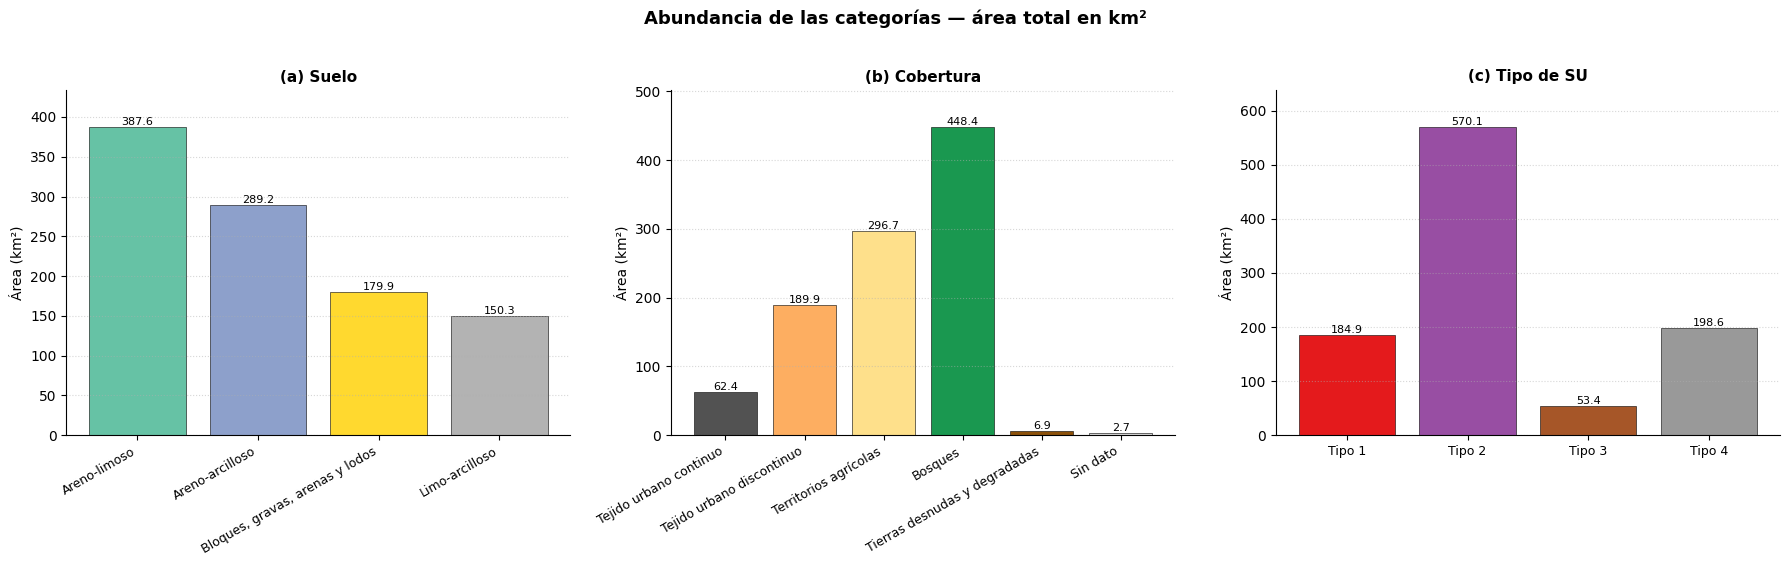

In [14]:
def barras_abundancia(
    su: gpd.GeoDataFrame,
    columna: str,
    color_dict: dict,
    titulo: str,
    orden: Optional[list] = None,
    ax: Optional[plt.Axes] = None,
    color_nan: str = '#d9d9d9',
) -> plt.Axes:
    """Gráfico de barras de área (km²) por categoría."""
    # Recalculo el área desde la geometría (en m², por estar en EPSG:3116) -> km².
    # No uso la columna `area` del GPKG porque sus unidades pueden variar entre datasets.
    area_m2 = su.geometry.area
    area_km2 = area_m2.groupby(su[columna].values, dropna=False).sum() / 1e6
    area_km2.index.name = columna

    # Orden de las barras
    cats = orden if orden is not None else list(color_dict.keys())
    valores = [area_km2.get(c, 0) for c in cats]
    colores = [color_dict.get(c, color_nan) for c in cats]

    # Categoría 'Sin dato' al final si hay NaN
    nan_area = area_km2[area_km2.index.isna()].sum() if area_km2.index.hasnans else 0
    if nan_area > 0:
        cats = list(cats) + ['Sin dato']
        valores.append(nan_area)
        colores.append(color_nan)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(range(len(cats)), valores, color=colores, edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels([str(c) for c in cats], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Área (km²)', fontsize=10)
    ax.set_title(titulo, fontsize=11, weight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Etiquetas encima de cada barra
    for b, v in zip(bars, valores):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max(valores) * 1.12)
    return ax


# Diccionarios de color (los mismos que usamos en los mapas)
orden_suelos = gdf['suelos'].value_counts().index.tolist()  # mismo orden que en el mapa

orden_cobertura_g = [
    'Tejido urbano continuo',
    'Tejido urbano discontinuo',
    'Territorios agrícolas',
    'Bosques',
    'Tierras desnudas y degradadas',
]

orden_su_type_g = sorted(gdf['su_type'].unique())
color_su_type_int = {int(t): color_sutype_legible[f'Tipo {int(t)}'] for t in orden_su_type_g}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

barras_abundancia(gdf, 'suelos',    color_suelos,    titulo='(a) Suelo',
                  orden=orden_suelos, ax=axes[0])
barras_abundancia(gdf, 'cobertura', color_cobertura, titulo='(b) Cobertura',
                  orden=orden_cobertura_g, ax=axes[1])
barras_abundancia(gdf, 'su_type',   color_su_type_int, titulo='(c) Tipo de SU',
                  orden=orden_su_type_g, ax=axes[2])
axes[2].set_xticklabels([f'Tipo {int(t)}' for t in orden_su_type_g], rotation=0, ha='center')

fig.suptitle('Abundancia de las categorías — área total en km²', fontsize=13, weight='bold', y=1.02)
fig.tight_layout()
plt.show()

## 11. Gráficos de barras — densidad de MM (eventos/km²)

Barras agrupadas: dos barras por categoría, una por inventario. Permite contrastar el patrón observado por SIATA con el de sensores remotos.

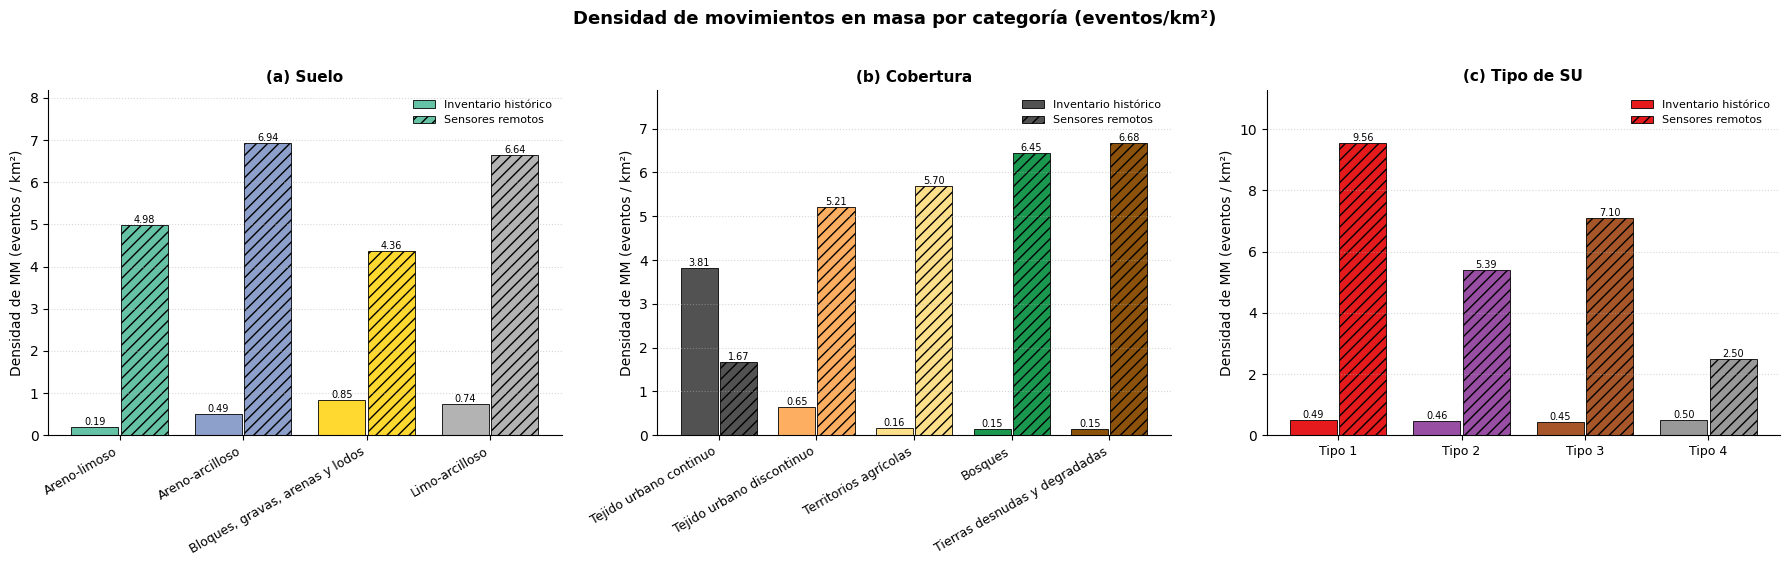

In [15]:
def barras_densidad_mm(
    su: gpd.GeoDataFrame,
    columna: str,
    mm_inventarios: dict,
    color_dict: dict,
    titulo: str,
    orden: Optional[list] = None,
    ax: Optional[plt.Axes] = None,
    color_nan: str = '#d9d9d9',
) -> plt.Axes:
    """Barras agrupadas de densidad de MM (eventos/km²) por categoría e inventario.

    El color de fondo (alpha bajo) es el color de la categoría; el contorno y la
    intensidad distinguen el inventario.
    """
    # Área km² por categoría
    # Recalculo el área desde la geometría (en m², por estar en EPSG:3116) -> km².
    # No uso la columna `area` del GPKG porque sus unidades pueden variar entre datasets.
    area_m2 = su.geometry.area
    area_km2 = area_m2.groupby(su[columna].values, dropna=False).sum() / 1e6
    area_km2.index.name = columna

    cats = orden if orden is not None else list(color_dict.keys())
    n_invs = len(mm_inventarios)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    width = 0.8 / n_invs
    x = np.arange(len(cats))

    # Hatches para distinguir inventarios sin depender del color
    hatches = ['', '///', '...']

    for i, (etiq, mm) in enumerate(mm_inventarios.items()):
        n = mm.groupby(columna, dropna=False).size()
        dens = []
        for c in cats:
            a = area_km2.get(c, 0)
            ni = n.get(c, 0)
            dens.append(ni / a if a > 0 else np.nan)

        offset = -0.4 + (i + 0.5) * width
        colores = [color_dict.get(c, color_nan) for c in cats]

        bars = ax.bar(
            x + offset, dens, width=width * 0.95,
            color=colores, edgecolor='black', linewidth=0.6,
            hatch=hatches[i % len(hatches)], label=etiq,
        )
        for b, v in zip(bars, dens):
            if v is not None and not np.isnan(v):
                ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                        ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Densidad de MM (eventos / km²)', fontsize=10)
    ax.set_title(titulo, fontsize=11, weight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ymax = max([b.get_height() for b in ax.patches if not np.isnan(b.get_height())], default=1)
    ax.set_ylim(0, ymax * 1.18)
    ax.legend(fontsize=8, frameon=False, loc='upper right')
    return ax


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

barras_densidad_mm(gdf, 'suelos',    inventarios, color_suelos,
                   titulo='(a) Suelo',     orden=orden_suelos,       ax=axes[0])
barras_densidad_mm(gdf, 'cobertura', inventarios, color_cobertura,
                   titulo='(b) Cobertura', orden=orden_cobertura_g,  ax=axes[1])
barras_densidad_mm(gdf, 'su_type',   inventarios, color_su_type_int,
                   titulo='(c) Tipo de SU', orden=orden_su_type_g,   ax=axes[2])
axes[2].set_xticklabels([f'Tipo {int(t)}' for t in orden_su_type_g], rotation=0, ha='center')

fig.suptitle('Densidad de movimientos en masa por categoría (eventos/km²)',
             fontsize=13, weight='bold', y=1.02)
fig.tight_layout()
plt.show()